# Measured vs simulated antenna reflection coefficient for the EIGSEP bowtie

Two-row, single-column figure (`s11_sim_meas.pdf`):

- **top** -- |Gamma_ant| in dB vs frequency: HFSS simulation (dashed grey) and
  the field measurement (solid black), with a -10 dB guide line.
- **bottom** -- delay spectrum of the *measured* S11 only, in dB relative to
  its global peak, with a secondary axis in round-trip reflector distance
  d = c*tau/2.

There is deliberately no simulated curve in the bottom panel: `sparams.csv` is
magnitude-only (no phase) and the HFSS model is free space, so it contains no
terrain and would show nothing at terrain delays even if the phase existed.

Measurement: field OSL calibration, lab-measured S-parameters de-embedded
(MIST approach). Simulation: HFSS, `sparams.csv`.
Style follows `s11-plot.ipynb` so the figure matches the rest of the paper.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import eigsep_style as es

HERE = "."   # inputs sit beside the notebook
OUT = "."    # the figure is deposited here

C_M_PER_NS = 299792458.0 * 1e-9  # speed of light, m/ns
FMIN, FMAX = 50e6, 250e6         # analysis band [Hz]
GAP_EDGE_NS = 590.0              # marked in the bottom panel

# 7-term Blackman-Harris.  The low sidelobes matter: the delay-0 impedance
# mismatch peak is of order unity while the terrain feature is ~43 dB above
# the noise floor and ~50 dB below the peak, so a weaker window would show its
# own sidelobes at exactly the delays we care about.
BH7 = [
    0.27105140069342,
    0.43329793923448,
    0.21812299954311,
    0.06592544638803,
    0.01081174209837,
    0.00077658482522,
    0.00001388721735,
]


In [2]:
def blackman_harris7(n_samp):
    """Mean-normalised 7-term Blackman-Harris window of length ``n_samp``."""
    n = np.arange(n_samp)
    w = np.zeros(n_samp)
    for k, a in enumerate(BH7):
        w += (-1) ** k * a * np.cos(2 * np.pi * k * n / (n_samp - 1))
    return w / w.mean()


def load_measurement():
    """Calibrated, de-embedded antenna S11 restricted to the analysis band."""
    d = np.load(f"{HERE}/s11.npz")
    f = d["freqs"]
    g = d["calibrated_s11"]
    cut = (f >= FMIN) & (f <= FMAX)
    return f[cut], g[cut]


def load_simulation():
    sim = np.loadtxt(f"{HERE}/sparams.csv", delimiter=",", skiprows=1,
                     usecols=(1, 2))
    return sim[:, 0], sim[:, 1]


def delay_spectrum(f, g):
    """Windowed delay spectrum of a complex reflection coefficient.

    Uses ``np.fft.ifft`` paired with ``np.fft.fftfreq`` so that environmental
    reflections land at POSITIVE delay, matching the sign convention of the
    simulated environmental delay spectrum in reflections.pdf (which quotes its
    gap edge at 600-670 ns).  ``np.fft.fft`` with the same axis puts them at
    negative delay.

    Returns (delay [ns], dB relative to the GLOBAL peak), sorted by delay.
    The global peak sits slightly off zero delay (+20 ns), so it must be taken
    over the whole spectrum, not over a one-sided slice.
    """
    n_samp = f.size
    df = np.median(np.diff(f))
    spec = np.fft.ifft(g * blackman_harris7(n_samp))
    tau = np.fft.fftfreq(n_samp, d=df) * 1e9  # ns
    amp = np.abs(spec)
    db = 20 * np.log10(amp / amp.max())
    order = np.argsort(tau)
    tau, db = tau[order], db[order]

    # Guard the sign convention: the environmental feature must sit at
    # positive delay.  Swapping ifft->fft (or negating tau) silently mirrors
    # the spectrum and would contradict Fig. reflections.pdf.
    pos = db[(tau > 300) & (tau < 1200)].max()
    neg = db[(tau < -300) & (tau > -1200)].max()
    if pos <= neg:
        raise RuntimeError(
            f"environmental feature landed at negative delay "
            f"({pos:.1f} dB positive vs {neg:.1f} dB negative); "
            "check the ifft/fftfreq sign convention"
        )
    return tau, db


In [3]:
def plot_frequency(ax, f_meas_mhz, s_meas_db, f_sim, s_sim, legend=True):
    ax.plot(f_sim, s_sim, c="0.55", ls="--", lw=1.1, label="Simulation")
    ax.plot(f_meas_mhz, s_meas_db, c="k", lw=1.0, label="Measurement")
    ax.axhline(-10, c="0.75", ls=":", lw=0.8, zorder=0)
    ax.set_xlabel("Frequency [MHz]", fontsize=8)
    ax.set_ylabel(r"|$\Gamma_{\rm ant}$| [dB]", fontsize=8)
    ax.set_ylim(-23, 0)
    ax.set_xlim(50, 250)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.4)
    if legend:
        ax.legend(fontsize=7, loc="upper right", framealpha=0.9)


def plot_delay(ax, tau, db, floor=None):  # floor kept for callers; not drawn
    ax.plot(tau, db, c="k", lw=0.8)
    # Gap edge. Darker and dashed rather than dotted grey: it sits one pixel
    # from a gridline at 600 ns and the dotted version was indistinguishable
    # from it. No arrow -- the label sits directly beside the line.
    ax.axvline(GAP_EDGE_NS, c="0.35", ls="--", lw=0.9, zorder=2)
    ax.text(
        GAP_EDGE_NS + 22, -12,
        f"{C_M_PER_NS * GAP_EDGE_NS / 2:.0f}" + r"$\,$m",
        fontsize=7, color="0.35", ha="left", va="center",
    )
    ax.set_xlabel("Delay [ns]", fontsize=8)
    ax.set_ylabel("Delay spectrum [dB]", fontsize=8)
    ax.set_xlim(0, 1050)
    ax.set_ylim(-105, 5)
    ax.set_xticks(np.arange(0, 1001, 200))
    ax.set_yticks(np.arange(-100, 1, 20))
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.4)

    secax = ax.secondary_xaxis(
        "top",
        functions=(lambda t: C_M_PER_NS * t / 2, lambda d: 2 * d / C_M_PER_NS),
    )
    secax.set_xlabel("Reflector distance [m]", fontsize=8, labelpad=2)
    secax.set_xticks([0, 50, 100, 150])
    secax.tick_params(labelsize=7)
    secax.spines["top"].set_visible(False)  # avoid doubling the panel frame


In [4]:
def main():
    f_meas, g_meas = load_measurement()
    f_meas_mhz = f_meas / 1e6
    s_meas = 20 * np.log10(np.abs(g_meas))
    f_sim, s_sim = load_simulation()

    tau, db = delay_spectrum(f_meas, g_meas)
    floor = np.median(db[np.abs(tau) > 1200])

    fig, (ax0, ax1) = es.figure(cols=1, height_in=4.4163, nrows=2, ncols=1)
    fig.get_layout_engine().set(h_pad=0.10, hspace=0.06)
    plot_frequency(ax0, f_meas_mhz, s_meas, f_sim, s_sim)
    plot_delay(ax1, tau, db, floor)
    # Panel labels -- the body text refers to Fig. X(a) and X(b). Placed in
    # axes coords just inside the top-left corner of each panel; (b)'s corner
    # is empty and (a)'s curve starts well below 0 dB there.
    # Inset from the corner rather than flush against it: the delay-0 mismatch
    # peak in (b) reaches 0 dB within a few pixels of the axis, so a flush
    # label collides with it, and an opaque box would hide the peak's apex.
    # At x = 0.10 both panels are empty at the top -- (a) is at -7 dB there and
    # (b) is already down at -85 dB. Same coordinates in both, so they align.
    for ax, lab in ((ax0, "(a)"), (ax1, "(b)")):
        ax.text(0.10, 0.955, lab, transform=ax.transAxes, fontsize=8,
                fontweight="bold", ha="left", va="top", color="k", zorder=6)
    es.save(fig, f"{OUT}/s11_sim_meas.pdf")
    return f_meas_mhz, s_meas, f_sim, s_sim, tau, db, floor


In [5]:
# --- numbers for the manuscript text ---
def stays_below(fr, sd, thr=-10):
    ok = sd < thr
    idx = [i for i in range(len(ok)) if ok[i:].all()]
    return fr[idx[0]] if idx else None


def report(f_meas, s_meas, f_sim, s_sim, tau, db, floor):
    s_sim_i = np.interp(f_meas, f_sim, s_sim)
    diff = np.abs(s_meas - s_sim_i)
    print(f"measurement stays < -10 dB above : {stays_below(f_meas, s_meas):.1f} MHz")
    print(f"simulation  stays < -10 dB above : {stays_below(f_sim, s_sim):.1f} MHz")
    print(f"median |meas - sim| over 50-250  : {np.median(diff):.1f} dB")
    print(f"max    |meas - sim| over 50-250  : {np.max(diff):.1f} dB  (at {f_meas[np.argmax(diff)]:.0f} MHz)")
    for band, lo, hi in [("50-85", 50, 85), ("85-250", 85, 250)]:
        m = (f_meas >= lo) & (f_meas <= hi)
        print(f"  median |meas - sim| {band} MHz    : {np.median(diff[m]):.1f} dB")
    print(f"measured |Gamma| range 85-250    : {s_meas[f_meas>=85].min():.1f} to {s_meas[f_meas>=85].max():.1f} dB")

    if tau is None:
        return
    dist = C_M_PER_NS * tau / 2
    print()
    print(f"delay resolution / range         : {np.diff(np.sort(tau))[0]:.1f} ns / +-{tau.max():.0f} ns")
    i = np.argmax(db)
    print(f"global peak (mismatch)           : {tau[i]:+.1f} ns ({dist[i]:.1f} m)")
    m = (tau > 300) & (tau < 1200)
    j = np.argmax(db[m])
    print(f"environmental feature peak       : {tau[m][j]:.0f} ns = {dist[m][j]:.0f} m at {db[m][j]:.1f} dB")
    print(f"noise floor (|delay| > 1200 ns)  : {floor:.1f} dB")
    print(f"feature above floor              : {db[m][j] - floor:+.1f} dB")
    # extent above floor+20 dB, bridging single-sample nulls
    thr = floor + 20
    pos = tau > 0
    t, y, d = tau[pos], db[pos], dist[pos]
    ys = np.median(np.stack([np.roll(y, 1), y, np.roll(y, -1)]), axis=0)
    pk = np.argmax(np.where((t > 300) & (t < 1200), y, -np.inf))
    lo = pk
    while lo > 0 and ys[lo - 1] > thr:
        lo -= 1
    hi = pk
    while hi < y.size - 1 and ys[hi + 1] > thr:
        hi += 1
    print(f"gap edge (first sample > floor+20): {t[lo]:.0f} ns = {d[lo]:.0f} m")
    print(f"feature extent above floor+20 dB : {t[lo]:.0f}-{t[hi]:.0f} ns = {d[lo]:.0f}-{d[hi]:.0f} m")
    q = (t > 100) & (t < GAP_EDGE_NS - 20)
    print(f"inside the gap (100-570 ns)      : median {np.median(y[q]):.1f} dB (floor {floor:.1f})")


measurement stays < -10 dB above : 85.2 MHz
simulation  stays < -10 dB above : 84.0 MHz
median |meas - sim| over 50-250  : 2.1 dB
max    |meas - sim| over 50-250  : 8.2 dB  (at 134 MHz)
  median |meas - sim| 50-85 MHz    : 0.5 dB
  median |meas - sim| 85-250 MHz    : 3.1 dB
measured |Gamma| range 85-250    : -21.3 to -10.1 dB

delay resolution / range         : 5.0 ns / +-2004 ns
global peak (mismatch)           : +20.0 ns (3.0 m)
environmental feature peak       : 605 ns = 91 m at -50.0 dB
noise floor (|delay| > 1200 ns)  : -93.4 dB
feature above floor              : +43.4 dB
gap edge (first sample > floor+20): 590 ns = 88 m
feature extent above floor+20 dB : 590-849 ns = 88-127 m
inside the gap (100-570 ns)      : median -98.5 dB (floor -93.4)


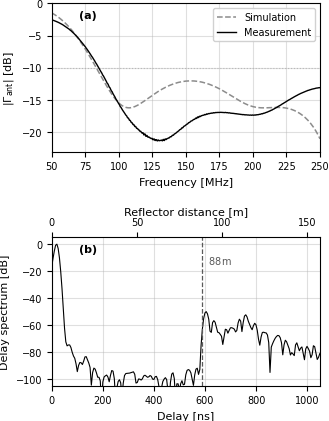

In [6]:
result = main()
report(*result)
